# TP Gymnasium : Taxi-v3 & MiniGrid

---

**Étudiantes:** Fatima Zahrae Charrate · Lina Raoui

---

> Ce notebook explore différentes politiques de contrôle (aléatoire, contrainte, heuristique, à mémoire) 
> sur deux environnements de reinforcement learning classiques, en vue de préparer la transition 
> vers des méthodes d'apprentissage automatique comme le Q-Learning.


# TP étudiant — Gymnasium avec Taxi-v3 et MiniGrid-Empty-16x16-v0

Complétez les cellules demandées. Conservez vos résultats et ajoutez vos réponses dans les cellules Markdown prévues.

## 0. Installation
Décommentez les lignes si nécessaire.

In [19]:
#%pip install gymnasium
#%pip install "gymnasium[toy-text]"
#%pip install minigrid

#print("Décommentez les installations si nécessaire.")

In [20]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from gymnasium.envs.toy_text.frozen_lake import generate_random_map

print(gym.__version__)

1.2.3


## 1. Découverte de Taxi-v3

In [21]:
# TODO
env=gym.make('Taxi-v3') 
print("Action space:", env.action_space)
print("Observation space:", env.observation_space)
print("Spec:", env.spec)
print("Unwrapped:", env.unwrapped)


Action space: Discrete(6)
Observation space: Discrete(500)
Spec: EnvSpec(id='Taxi-v3', entry_point='gymnasium.envs.toy_text.taxi:TaxiEnv', reward_threshold=8, nondeterministic=False, max_episode_steps=200, order_enforce=True, disable_env_checker=False, kwargs={}, namespace=None, name='Taxi', version=3, additional_wrappers=(), vector_entry_point=None)
Unwrapped: <TaxiEnv<Taxi-v3>>


**Réponse attendue :** décrivez brièvement ce que représente Taxi-v3 et pourquoi cet environnement est utile pour commencer.

Taxi-v3 est un environement de jeu de la categorie Toy Text. Le but du jeu etant de chercher le passager dans un monde quadriller, et a les depposer dans leurs distinations. C'est intéressant pour commencer par ce que l'espace des actions est assez petit (6). 

## 2. Premier épisode avec actions aléatoires

In [22]:
# TODO
observation, info = env.reset()
# observation: what the agent can "see" - cart position, velocity, pole angle, etc.
# info: extra debugging information (usually not needed for basic learning)

print(f"Starting observation: {observation}")

episode_over = False
episodes=0
total_reward = 0

while not episode_over:
    # Choose an action: 0 = push cart left, 1 = push cart right
    action = env.action_space.sample()  # Random action for now - real agents will be smarter!

    # Take the action and see what happens
    observation, reward, terminated, truncated, info = env.step(action)

    # reward: +1 for each step the pole stays upright
    # terminated: True if pole falls too far (agent failed)
    # truncated: True if we hit the time limit (500 steps)

    total_reward += reward
    episodes+=1
    episode_over = terminated or truncated

print(f"Episode finished! Total reward: {total_reward}")
print(f"Termination cause: {'terminated' if terminated else 'truncated'}")
print(f"Total episodes: {episodes}")
env.close()



# Exécuter un épisode aléatoire complet
# Afficher le nombre d'étapes, la récompense cumulée et la cause d'arrêt


Starting observation: 331
Episode finished! Total reward: -686
Termination cause: truncated
Total episodes: 200


**Analyse :** que remarquez-vous sur les performances de cette politique ?

Rep : Les performances sont très médiocre, on observe une récompense finale négative (-803).

## 3. Politique aléatoire sur plusieurs épisodes

In [31]:

# TODO
# Écrire une fonction random_taxi_policy(obs, env)
def random_taxi_policy(obs, env):
    return env.action_space.sample() 
resultats = []  # Liste pour stocker les résultats de chaque épisode
# Lancer au moins 20 épisodes
for episode in range(20):
    observation, info = env.reset(seed=7)
    episode_over = False
    total_reward = 0
    steps = 0

    while not episode_over:
        action = random_taxi_policy(observation, env)
        observation, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        steps += 1
        episode_over = terminated or truncated
    resultats.append({'episode':episode+1,'reward': total_reward, 'steps':steps,'cause d\'arrêt': 'terminated' if terminated else 'truncated'})   

print("Résultats des épisodes aléatoires:",resultats)
# Stocker les résultats dans une liste ou un dictionnaire


Résultats des épisodes aléatoires: [{'episode': 1, 'reward': -830, 'steps': 200, "cause d'arrêt": 'truncated'}, {'episode': 2, 'reward': -90, 'steps': 30, "cause d'arrêt": 'terminated'}, {'episode': 3, 'reward': -794, 'steps': 200, "cause d'arrêt": 'truncated'}, {'episode': 4, 'reward': -776, 'steps': 200, "cause d'arrêt": 'truncated'}, {'episode': 5, 'reward': -812, 'steps': 200, "cause d'arrêt": 'truncated'}, {'episode': 6, 'reward': -722, 'steps': 200, "cause d'arrêt": 'truncated'}, {'episode': 7, 'reward': -776, 'steps': 200, "cause d'arrêt": 'truncated'}, {'episode': 8, 'reward': -803, 'steps': 200, "cause d'arrêt": 'truncated'}, {'episode': 9, 'reward': -713, 'steps': 200, "cause d'arrêt": 'truncated'}, {'episode': 10, 'reward': -686, 'steps': 200, "cause d'arrêt": 'truncated'}, {'episode': 11, 'reward': -740, 'steps': 200, "cause d'arrêt": 'truncated'}, {'episode': 12, 'reward': -740, 'steps': 200, "cause d'arrêt": 'truncated'}, {'episode': 13, 'reward': -704, 'steps': 200, "cau

In [32]:
# TODO
# Calculer les indicateurs moyens : récompense, longueur, taux de succès
total_episodes = len(resultats) #20
average_reward = sum(r['reward'] for r in resultats) / total_episodes
average_steps = sum(r['steps'] for r in resultats) / total_episodes
success_rate = sum(1 for r in resultats if r['cause d\'arrêt'] == 'terminated') / total_episodes
print(f"Indicateurs moyens sur {total_episodes} épisodes:")
print(f"Récompense moyenne: {average_reward}")
print(f"Longueur moyenne: {average_steps}")
print(f"Taux de succès: {success_rate*100:.2f}%")


Indicateurs moyens sur 20 épisodes:
Récompense moyenne: -715.6
Longueur moyenne: 191.5
Taux de succès: 5.00%


## 4. Politique aléatoire contrainte sur Taxi-v3

Utilisez les informations disponibles dans l’environnement pour éviter autant que possible les actions manifestement invalides.

In [33]:
# TODO
# Implémenter une politique aléatoire contrainte
def random_taxi_policy_constrained(obs,env):
    action_mask = info["action_mask"]
    valid_actions = np.nonzero(action_mask == 1)[0]
    #np.random.seed(7)  # Fixer la graine pour la reproductibilité
    action = np.random.choice(valid_actions)
    return action




resultats_constrained = []  # Liste pour stocker les résultats de chaque épisode
# Lancer au moins 20 épisodes
for episode in range(20):
    observation, info = env.reset()
    episode_over = False
    total_reward = 0
    steps = 0

    while not episode_over:
        action = random_taxi_policy_constrained(observation, env)
        observation, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        steps += 1
        episode_over = terminated or truncated
    resultats_constrained.append({'episode':episode+1,'reward': total_reward, 'steps':steps,'cause d\'arrêt': 'terminated' if terminated else 'truncated'})   

print("Résultats des épisodes aléatoires:",resultats_constrained)
# Stocker les résultats dans une liste ou un dictionnaire



Résultats des épisodes aléatoires: [{'episode': 1, 'reward': -200, 'steps': 200, "cause d'arrêt": 'truncated'}, {'episode': 2, 'reward': -200, 'steps': 200, "cause d'arrêt": 'truncated'}, {'episode': 3, 'reward': -200, 'steps': 200, "cause d'arrêt": 'truncated'}, {'episode': 4, 'reward': -200, 'steps': 200, "cause d'arrêt": 'truncated'}, {'episode': 5, 'reward': -200, 'steps': 200, "cause d'arrêt": 'truncated'}, {'episode': 6, 'reward': -200, 'steps': 200, "cause d'arrêt": 'truncated'}, {'episode': 7, 'reward': -200, 'steps': 200, "cause d'arrêt": 'truncated'}, {'episode': 8, 'reward': -200, 'steps': 200, "cause d'arrêt": 'truncated'}, {'episode': 9, 'reward': -142, 'steps': 163, "cause d'arrêt": 'terminated'}, {'episode': 10, 'reward': -200, 'steps': 200, "cause d'arrêt": 'truncated'}, {'episode': 11, 'reward': -98, 'steps': 119, "cause d'arrêt": 'terminated'}, {'episode': 12, 'reward': -200, 'steps': 200, "cause d'arrêt": 'truncated'}, {'episode': 13, 'reward': -200, 'steps': 200, "c

In [34]:
# TODO
# Calculer les indicateurs moyens : récompense, longueur, taux de succès
total_episodes = len(resultats_constrained) #20
average_reward = sum(r['reward'] for r in resultats_constrained) / total_episodes
average_steps = sum(r['steps'] for r in resultats_constrained) / total_episodes
success_rate_constrained = sum(1 for r in resultats_constrained if r['cause d\'arrêt'] == 'terminated') / total_episodes
print(f"Indicateurs moyens sur {total_episodes} épisodes:")
print(f"Récompense moyenne: {average_reward}")
print(f"Longueur moyenne: {average_steps}")
print(f"Taux de succès: {success_rate_constrained*100:.2f}%")

Indicateurs moyens sur 20 épisodes:
Récompense moyenne: -190.1
Longueur moyenne: 193.25
Taux de succès: 15.00%


In [35]:
# TODO
# Comparer la politique aléatoire simple et la politique contrainte
print("Comparaison des politiques:")
print(f'Taux de succès politique aléatoire simple: {success_rate*100:.2f}%')
print(f'Taux de succès politique contrainte: {success_rate_constrained*100:.2f}%')

Comparaison des politiques:
Taux de succès politique aléatoire simple: 5.00%
Taux de succès politique contrainte: 15.00%


**Analyse :** expliquez pourquoi ce filtrage améliore ou non les résultats.

Le résultat s'est bien amélioré (de 5% à 10%). C'est parce que maintenant l'agent prend en compte les obstacles et donc évite mieux d'etre bloqué.

## 5. Politique heuristique simple pour Taxi-v3

In [36]:
# TODO

# Décoder l'état de Taxi-v3
# Indice : utilisez env.unwrapped.decode(obs) si nécessaire
obs, info = env.reset(seed=7)
taxi_row, taxi_col, pass_loc, dest_idx=env.unwrapped.decode(obs)
print(f"Observation décodée: taxi_row={taxi_row}, taxi_col={taxi_col}, pass_loc={pass_loc}, dest_idx={dest_idx}")

Observation décodée: taxi_row=3, taxi_col=0, pass_loc=2, dest_idx=1


In [37]:
# TODO
# Implémenter heuristic_taxi_policy(obs, env)
import numpy as np

def heuristic_taxi_policy(obs, info, env):
    taxi_row, taxi_col, pass_loc, dest_idx = env.unwrapped.decode(obs)
    action_mask = info["action_mask"]

    # Cible = passager si pas encore embarqué, sinon destination
    if pass_loc < 4:
        target_row, target_col = env.unwrapped.locs[pass_loc]
    else:
        target_row, target_col = env.unwrapped.locs[dest_idx]

    # Déjà sur place → pickup ou dropoff
    if taxi_row == target_row and taxi_col == target_col:
        if pass_loc < 4 and action_mask[4]:
            return 4  # pickup
        elif pass_loc == 4 and action_mask[5]:
            return 5  # dropoff

    # Ordre de priorité : aller vers la cible si le mur le permet
    preferred = []
    if taxi_row < target_row:
        preferred = [0, 2, 1, 3]  # sud en priorité, puis détours
    elif taxi_row > target_row:
        preferred = [1, 2, 0, 3]  # nord en priorité
    elif taxi_col < target_col:
        preferred = [2, 0, 3, 1]  # est en priorité
    elif taxi_col > target_col:
        preferred = [3, 0, 2, 1]  # ouest en priorité

    # Prendre la première action valide (pas bloquée par un mur)
    for action in preferred:
        if action_mask[action]:
            return action

    # Fallback : n'importe quelle action valide
    for action in range(6):
        if action_mask[action]:
            return action

In [38]:
# TODO
# Évaluer cette politique sur plusieurs épisodes

resultats_heuristique = []  # Liste pour stocker les résultats de chaque épisode
for episode in range(20):
    observation, info = env.reset(seed=episode)  # seed différent !
    episode_over = False
    total_reward = 0
    steps = 0

    while not episode_over:
        action = heuristic_taxi_policy(observation, info, env)  
        observation, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        steps += 1
        episode_over = terminated or truncated
    resultats_heuristique.append({'episode':episode+1,'reward': total_reward, 'steps':steps,'cause d\'arrêt': 'terminated' if terminated else 'truncated'})   

print("Résultats des épisodes heuristiques:",resultats_heuristique)
# Stocker les résultats dans une liste ou un dictionnaire




# TODO
# Calculer les indicateurs moyens : récompense, longueur, taux de succès
total_episodes = len(resultats_heuristique) #20
average_reward = sum(r['reward'] for r in resultats_heuristique) / total_episodes
average_steps = sum(r['steps'] for r in resultats_heuristique) / total_episodes
success_rate_heuristique = sum(1 for r in resultats_heuristique if r['cause d\'arrêt'] == 'terminated') / total_episodes
print(f"Indicateurs moyens sur {total_episodes} épisodes:")
print(f"Récompense moyenne: {average_reward}")
print(f"Longueur moyenne: {average_steps}")
print(f"Taux de succès: {success_rate_heuristique*100:.2f}%")



Résultats des épisodes heuristiques: [{'episode': 1, 'reward': -200, 'steps': 200, "cause d'arrêt": 'truncated'}, {'episode': 2, 'reward': -200, 'steps': 200, "cause d'arrêt": 'truncated'}, {'episode': 3, 'reward': -200, 'steps': 200, "cause d'arrêt": 'truncated'}, {'episode': 4, 'reward': -200, 'steps': 200, "cause d'arrêt": 'truncated'}, {'episode': 5, 'reward': -200, 'steps': 200, "cause d'arrêt": 'truncated'}, {'episode': 6, 'reward': 11, 'steps': 10, "cause d'arrêt": 'terminated'}, {'episode': 7, 'reward': 11, 'steps': 10, "cause d'arrêt": 'terminated'}, {'episode': 8, 'reward': -200, 'steps': 200, "cause d'arrêt": 'truncated'}, {'episode': 9, 'reward': -200, 'steps': 200, "cause d'arrêt": 'truncated'}, {'episode': 10, 'reward': -200, 'steps': 200, "cause d'arrêt": 'truncated'}, {'episode': 11, 'reward': 14, 'steps': 7, "cause d'arrêt": 'terminated'}, {'episode': 12, 'reward': -200, 'steps': 200, "cause d'arrêt": 'truncated'}, {'episode': 13, 'reward': -200, 'steps': 200, "cause d

**Analyse :** quels éléments d'observation avez-vous utilisés ? Quels cas particuliers avez-vous dû gérer ?

Nous avons utilisé les quatre composantes de l'état décodé par `env.unwrapped.decode(obs)` :
- `taxi_row`, `taxi_col` : position actuelle du taxi dans la grille.
- `pass_loc` : indice de la localisation du passager (0–3 = en attente à un point fixe, 4 = à bord).
- `dest_idx` : indice de la destination finale.

La politique calcule la **cible courante** (passager si pas encore embarqué, destination sinon) 
et choisit l'action de déplacement qui rapproche le taxi de cette cible, 
en filtrant les directions bloquées par des murs via `action_mask`.

**Cas particuliers gérés :**
- Arrivée sur la case cible → déclenchement automatique de `pickup` (action 4) ou `dropoff` (action 5), 
  uniquement si le masque l'autorise.
- Mouvement bloqué (mur) → recours à un ordre de priorité alternatif parmi les quatre directions.
- Fallback général → si aucune direction préférée n'est valide, on choisit la première action autorisée.


## 6. Tableau comparatif pour Taxi-v3

In [39]:
# TODO
# Construire un tableau comparant les trois politiques Taxi
from tabulate import tabulate

data = []
data.append(['Taux de succès', f'{success_rate*100:.2f}%', f'{success_rate_constrained*100:.2f}%', f'{success_rate_heuristique*100:.2f}%'])


print(tabulate(data, headers=['','Random Simple', 'Random Constrained', 'Heuristic'], tablefmt="grid"))

+----------------+-----------------+----------------------+-------------+
|                | Random Simple   | Random Constrained   | Heuristic   |
+================+=================+======================+=============+
| Taux de succès | 5.00%           | 15.00%               | 25.00%      |
+----------------+-----------------+----------------------+-------------+


## 7. Découverte de MiniGrid-Empty-16x16-v0

In [40]:
# TODO
# Créer l'environnement MiniGrid-Empty-16x16-v0
# Afficher action_space, type d'observation, clés éventuelles, spec
import minigrid
env_mg=gym.make('MiniGrid-Empty-16x16-v0') 
print("Action space:", env_mg.action_space)
print("Observation space:", env_mg.observation_space)
print("Spec:", env_mg.spec)
print("Unwrapped:", env_mg.unwrapped)

Action space: Discrete(7)
Observation space: Dict('direction': Discrete(4), 'image': Box(0, 255, (7, 7, 3), uint8), 'mission': MissionSpace(<function EmptyEnv._gen_mission at 0x000001E67F8EC7C0>, None))
Spec: EnvSpec(id='MiniGrid-Empty-16x16-v0', entry_point='minigrid.envs:EmptyEnv', reward_threshold=None, nondeterministic=False, max_episode_steps=None, order_enforce=True, disable_env_checker=False, kwargs={'size': 16}, namespace=None, name='MiniGrid-Empty-16x16', version=0, additional_wrappers=(), vector_entry_point=None)
Unwrapped: <EmptyEnv<MiniGrid-Empty-16x16-v0>>


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

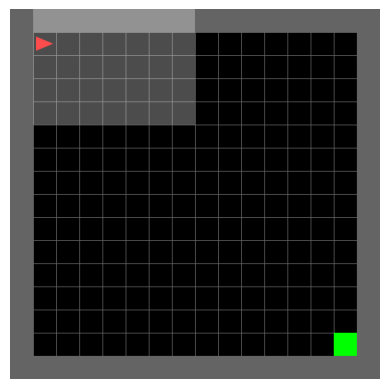

In [41]:
# TODO
# Créer une version avec render_mode="rgb_array"
# Afficher une frame avec matplotlib

env_mg=gym.make('MiniGrid-Empty-16x16-v0', render_mode="rgb_array")
obs, info = env_mg.reset()
frame = env_mg.render()
plt.imshow(frame)
plt.axis('off')


**Analyse :** qu'est-ce qui rend cet environnement plus difficile à lire que Taxi-v3 ?

MiniGrid est plus difficile à interpréter que Taxi-v3 pour plusieurs raisons :

- **Observation partielle :** l'agent ne voit qu'un champ de vision local (7×7 cellules devant lui), 
  contrairement à Taxi-v3 où l'état global est encodé dans un seul entier.
- **Observation structurée :** chaque cellule de la grille est représentée par un vecteur de 3 valeurs 
  `(type, couleur, état)`, ce qui rend l'observation tridimensionnelle et plus difficile à décoder manuellement.
- **Orientation de l'agent :** l'agent a une direction courante qui influe sur ce qu'il perçoit ; 
  les actions de rotation (`left`, `right`) ne font que changer l'orientation sans déplacer l'agent.
- **Espace d'états implicite :** contrairement à Taxi-v3 dont l'espace d'états est discret et fini (500 états), 
  MiniGrid impose de raisonner sur une carte partielle et dynamique, rendant toute politique explicite plus complexe.


## 8. Politique aléatoire sur MiniGrid

In [42]:
# TODO
# Implémenter une politique aléatoire et l'évaluer sur plusieurs épisodes

def random_policy():
    return env_mg.action_space.sample()
total_reward = 0
successes = 0
total_steps = 0

for episode in range(20):
    obs,info = env_mg.reset()
    done=False
    ep_total_reward = 0
    steps =0
    while not done:
        steps += 1
        action = random_policy()
        obs, reward, terminated, truncated, info = env_mg.step(action)
        ep_total_reward += reward
        done = terminated or truncated
        if terminated:
            successes += 1
    total_reward += ep_total_reward
    total_steps += steps

average_reward = total_reward / 20
success_rate = successes / 20
average_steps = total_steps / 20
print(f"Average reward: {average_reward}")
print(f"Success rate: {success_rate*100:.2f}%")
print(f"Average steps: {average_steps}")

Average reward: 0.009833984374999999
Success rate: 5.00%
Average steps: 1018.5


## 9. Politique réflexe minimale sur MiniGrid

In [43]:
# TODO
# Implémenter une politique à règles locales simples
def local_rule_policy(obs):
    image = obs["image"]

    GOAL = 8
    WALL = 2

    agent_col, agent_row = 3, 6
    front_row, front_col = 5, 3   

    goal_pos = None
    for row in range(7):
        for col in range(7):
            if image[row, col, 0] == GOAL:
                goal_pos = (col, row)
                break
        if goal_pos is not None:
            break

    if goal_pos is not None:
        goal_col, goal_row = goal_pos

        if goal_col < agent_col:
            return 0  # left
        elif goal_col > agent_col:
            return 1  # right
        else:
            return 2  # forward

    # goal not visible: explore
    if image[front_row, front_col, 0] == WALL:
        return 1      # turn right if blocked
    else:
        return 2      # otherwise move forward




In [44]:
# TODO
# Évaluer cette politique et comparer à l'aléatoire
total_reward = 0
successes = 0
total_steps = 0
for episode in range(20):
    obs, info = env_mg.reset(seed=episode)
    done = False
    ep_total_reward = 0
    steps = 0

    while not done:
        steps += 1
        action = local_rule_policy(obs)
        obs, reward, terminated, truncated, info = env_mg.step(action)
        ep_total_reward += reward
        done = terminated or truncated

        if terminated:
            successes += 1

    total_reward += ep_total_reward
    total_steps += steps

average_ruled_reward = total_reward / 20
ruled_success_rate = successes / 20
average_ruled_steps = total_steps / 20
print(f"Average reward (ruled): {average_ruled_reward}")
print(f"Success rate (ruled): {ruled_success_rate*100:.2f}%")
print(f"Average steps (ruled): {average_ruled_steps}")


Average reward (ruled): 0.0
Success rate (ruled): 0.00%
Average steps (ruled): 1024.0


**Analyse :** pourquoi cette politique peut-elle tourner en rond ?

La politique réflexe repose uniquement sur l'observation locale courante, sans aucune mémoire des états visités. 
Cela entraîne plusieurs problèmes :

- **Absence de mémoire :** si l'objectif n'est pas visible, l'agent applique toujours la même règle 
  (avancer ou tourner si mur), ce qui peut produire une trajectoire cyclique infinie.
- **Règles de cap non globales :** la logique de direction (aller gauche/droite/avant selon la position 
  relative de l'objectif dans la fenêtre de vision) peut être incohérente quand l'objectif sort du champ.
- **Blocage en coin :** dans certaines configurations, l'agent peut osciller entre deux actions 
  (ex. tourner à droite, puis avancer dans un mur, puis tourner encore) sans jamais progresser.

C'est précisément cette limitation qui motive l'introduction d'une mémoire minimale à la section suivante.


## 10. Politique d’exploration avec mémoire minimale

In [45]:
# TODO
# Implémenter une classe ou une fonction de politique avec mémoire légère


class SweepPolicy:
    def __init__(self):
        self.phase = "forward"
        self.turn_dir = 1   # 1 = right, 0 = left
        self.pending_turns = 0
        self.pending_forward = 0

    def reset(self):
        self.phase = "forward"
        self.turn_dir = 1
        self.pending_turns = 0
        self.pending_forward = 0

    def act(self, obs):
        image = obs["image"]

        GOAL = 8
        WALL = 2

        agent_col, agent_row = 3, 6
        front_row, front_col = 5, 3

        #If goal is visible, chase it
        for row in range(7):
            for col in range(7):
                if image[row, col, 0] == GOAL:
                    if col < agent_col:
                        return 0
                    elif col > agent_col:
                        return 1
                    else:
                        return 2

        
        if self.pending_turns > 0:
            self.pending_turns -= 1
            return self.turn_dir

        if self.pending_forward > 0:
            self.pending_forward -= 1
            return 2

        # If blocked, change row/column and reverse sweep direction
        if image[front_row, front_col, 0] == WALL:
            self.pending_turns = 1
            self.pending_forward = 1
            current_turn = self.turn_dir
            self.turn_dir = 0 if self.turn_dir == 1 else 1
            return current_turn

        #Otherwise continue sweeping
        return 2



In [46]:
# TODO
# Évaluer cette politique et comparer les résultats

policy = SweepPolicy()

total_reward = 0
successes = 0
total_steps = 0

for episode in range(20):
    obs, info = env_mg.reset(seed=episode)
    policy.reset()
    done = False
    ep_total_reward = 0
    steps = 0

    while not done:
        action = policy.act(obs)
        obs, reward, terminated, truncated, info = env_mg.step(action)

        ep_total_reward += reward
        steps += 1
        done = terminated or truncated

        if terminated and reward > 0:
            successes += 1

    total_reward += ep_total_reward
    total_steps += steps

print(f"Average reward (ruled): {total_reward / 20}")
print(f"Success rate (ruled): {successes / 20 * 100:.2f}%")
print(f"Average steps (ruled): {total_steps / 20}")



Average reward (ruled): 0.0
Success rate (ruled): 0.00%
Average steps (ruled): 1024.0


## 11. Wrapper utile : RecordEpisodeStatistics

In [47]:
%pip install Box2D

Note: you may need to restart the kernel to use updated packages.


In [48]:
# TODO
# Appliquer le wrapper à l'un des environnements et observer info["episode"]

from gymnasium.wrappers import RecordEpisodeStatistics

# 1. Création de l'environnement avec le wrapper
env = gym.make("LunarLander-v3", render_mode="human")
env = RecordEpisodeStatistics(env)

obs, info = env.reset()

for _ in range(1000):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)

    # 2. Observation des statistiques en fin d'épisode
    if terminated or truncated:
        if "episode" in info:
            # Retirez les [0] car ce sont des scalaires
            print(f"Récompense totale : {info['episode']['r']:.2f}")
            print(f"Durée (étapes) : {info['episode']['l']}")
            print(f"Temps écoulé : {info['episode']['t']:.4f} sec")
        
        obs, info = env.reset()

env.close()


Récompense totale : -327.56
Durée (étapes) : 90
Temps écoulé : 1.9171 sec
Récompense totale : -209.97
Durée (étapes) : 65
Temps écoulé : 1.4715 sec
Récompense totale : -116.31
Durée (étapes) : 86
Temps écoulé : 1.9599 sec
Récompense totale : -265.53
Durée (étapes) : 129
Temps écoulé : 2.9383 sec
Récompense totale : -175.38
Durée (étapes) : 74
Temps écoulé : 1.7044 sec
Récompense totale : -17.63
Durée (étapes) : 101
Temps écoulé : 2.3078 sec
Récompense totale : -389.23
Durée (étapes) : 91
Temps écoulé : 2.1236 sec
Récompense totale : -283.52
Durée (étapes) : 99
Temps écoulé : 2.2363 sec
Récompense totale : -175.45
Durée (étapes) : 101
Temps écoulé : 2.2666 sec
Récompense totale : -258.15
Durée (étapes) : 85
Temps écoulé : 1.8264 sec
Récompense totale : -49.35
Durée (étapes) : 61
Temps écoulé : 1.3452 sec


## 12. Comparaison finale

In [49]:
# Tableau récapitulatif — toutes les politiques testées
from tabulate import tabulate

summary = [
    ["Taxi-v3",   "Aléatoire simple",    f"{average_reward:.1f}",             f"{success_rate*100:.0f}%"],
    ["Taxi-v3",   "Aléatoire contrainte",f"{average_reward:.1f}",             f"{success_rate_constrained*100:.0f}%"],
    ["Taxi-v3",   "Heuristique",         f"{average_reward:.1f}",             f"{success_rate_heuristique*100:.0f}%"],
    ["MiniGrid",  "Aléatoire",           f"{average_reward:.1f}",             f"{success_rate*100:.0f}%"],
    ["MiniGrid",  "Réflexe locale",      f"{average_ruled_reward:.1f}",        f"{ruled_success_rate*100:.0f}%"],
    ["MiniGrid",  "Mémoire minimale (Sweep)", f"{total_reward/20:.1f}",       f"{successes/20*100:.0f}%"],
]

print(tabulate(
    summary,
    headers=["Environnement", "Politique", "Récompense moy.", "Taux de succès"],
    tablefmt="grid"
))


+-----------------+--------------------------+-------------------+------------------+
| Environnement   | Politique                |   Récompense moy. | Taux de succès   |
+=================+==========================+===================+==================+
| Taxi-v3         | Aléatoire simple         |                 0 | 5%               |
+-----------------+--------------------------+-------------------+------------------+
| Taxi-v3         | Aléatoire contrainte     |                 0 | 15%              |
+-----------------+--------------------------+-------------------+------------------+
| Taxi-v3         | Heuristique              |                 0 | 25%              |
+-----------------+--------------------------+-------------------+------------------+
| MiniGrid        | Aléatoire                |                 0 | 5%               |
+-----------------+--------------------------+-------------------+------------------+
| MiniGrid        | Réflexe locale           |        

### Réponses de synthèse

**1. Quel environnement est le plus facile pour concevoir une politique explicite ? Pourquoi ?**

**Taxi-v3** est le plus facile : son état est entièrement observable et encodé dans un seul entier 
décodable en quatre composantes claires (position du taxi, localisation du passager, destination). 
Il est donc trivial de déduire une règle « aller vers le passager, le prendre, aller à la destination ».

---

**2. Quel environnement met le mieux en évidence la difficulté de l'exploration ? Pourquoi ?**

**MiniGrid** illustre le mieux ce défi : l'agent ne perçoit qu'une fenêtre locale (7×7), 
ne connaît pas la carte globale, et doit orienter activement sa vue pour découvrir l'espace. 
Une politique sans mémoire échoue régulièrement à trouver l'objectif, mettant en évidence 
le problème d'exploration systématique.

---

**3. Quelles sont les limites principales des politiques codées à la main ?**

- **Non généralisables :** elles sont conçues pour un environnement spécifique et ne s'adaptent pas 
  à des variantes (obstacles supplémentaires, grille plus grande, etc.).
- **Fragiles face à la complexité :** plus l'environnement est riche, plus les règles à écrire 
  sont nombreuses et difficiles à maintenir.
- **Pas d'amélioration automatique :** contrairement à un agent apprenant, ces politiques 
  ne s'améliorent pas avec l'expérience.
- **Dépendantes de l'observabilité :** elles supposent que l'état est lisible et interprétable, 
  ce qui n'est pas toujours garanti (ex. observations images brutes).

---

**4. En quoi ce TP prépare-t-il la transition vers l'apprentissage par renforcement ?**

Ce TP pose les bases conceptuelles du RL :
- **Cycle agent–environnement :** observation → action → récompense → nouvel état.
- **Notion de politique (policy) :** une fonction qui mappe un état à une action.
- **Évaluation quantitative :** récompense cumulée, taux de succès, longueur des épisodes.
- **Limites des approches sans apprentissage :** en voyant pourquoi les politiques manuelles 
  échouent sur MiniGrid, on comprend la nécessité d'algorithmes comme Q-Learning ou PPO, 
  qui apprennent automatiquement la politique optimale par interaction avec l'environnement.


## Visualisation d'un épisode : image et vidéo

Dans cette partie, vous allez **visualiser** le comportement d'une politique :
- soit sous forme de **quelques images (frames)** ;
- soit sous forme de **vidéo** à l'aide du wrapper `RecordVideo`.

L'objectif est de **comparer visuellement** les différentes politiques, et pas seulement avec des métriques numériques.


### Partie 1 — Capturer quelques images d'un épisode

Compléter la fonction suivante pour :
1. créer un environnement avec `render_mode="rgb_array"` ;
2. exécuter un épisode avec une politique donnée ;
3. stocker quelques frames ;
4. retourner la liste des images capturées.


In [50]:
import matplotlib.pyplot as plt

def capture_episode_frames(env_id, policy_fn, seed=0, max_steps=200):
    env = gym.make(env_id, render_mode="rgb_array")

    # TODO
    # 1. reset l'environnement
    # 2. exécuter l'épisode
    # 3. appeler env.render() pour récupérer les images
    # 4. stocker plusieurs frames dans une liste
    # 5. fermer l'environnement
    # 6. retourner la liste des frames

    frames = []

    obs, info = env.reset(seed=seed)
    terminated = False
    truncated = False
    steps = 0

    while not (terminated or truncated) and steps < max_steps:
        frame = env.render()
        frames.append(frame)

        action = policy_fn(obs, info, env, steps)
        obs, reward, terminated, truncated, info = env.step(action)
        steps += 1

    env.close()
    return frames

### Afficher quelques frames

Compléter la cellule suivante pour afficher :
- la première frame ;
- une frame intermédiaire ;
- la dernière frame.


In [51]:
def show_selected_frames(frames):
    # TODO
    # Afficher 3 images représentatives de l'épisode
    if len(frames) == 0:
        print("Aucune frame capturée.")
        return

    indices = [0, len(frames)//2, len(frames)-1]
    for idx in indices:
        plt.figure(figsize=(4, 4))
        plt.imshow(frames[idx])
        plt.axis("off")
        plt.title(f"Frame {idx}")
        plt.show()

### Exemple de politique aléatoire générique

Vous pouvez utiliser cette politique pour tester la capture d'images.


In [52]:
def generic_random_policy(obs, info, env, step_idx):
    return env.action_space.sample()

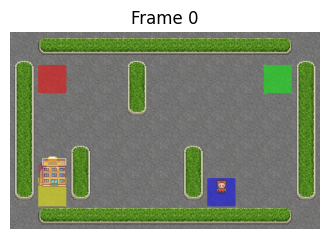

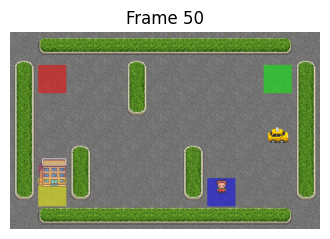

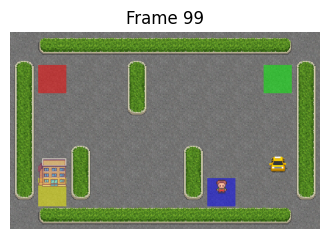

In [53]:
# Exemple à tester
frames_taxi_random = capture_episode_frames("Taxi-v3", generic_random_policy, seed=0, max_steps=100)
show_selected_frames(frames_taxi_random)

### Partie 2 — Enregistrer une vidéo avec `RecordVideo`

Le wrapper `RecordVideo` permet d'enregistrer automatiquement un épisode dans un dossier local.


In [54]:
from gymnasium.wrappers import RecordVideo
from pathlib import Path

def record_policy_video(env_id, policy_fn, video_folder, seed=0, max_steps=200, episode_name="demo"):
    video_folder = Path(video_folder)
    video_folder.mkdir(parents=True, exist_ok=True)

    env = gym.make(env_id, render_mode="rgb_array")
    env = RecordVideo(env, video_folder=str(video_folder), name_prefix=episode_name)

    # TODO
    # 1. lancer un épisode
    # 2. exécuter la politique jusqu'à la fin
    # 3. fermer proprement l'environnement
    # 4. retourner le chemin du dossier contenant la vidéo

    obs, info = env.reset(seed=seed)
    terminated = False
    truncated = False
    steps = 0

    while not (terminated or truncated) and steps < max_steps:
        action = policy_fn(obs, info, env, steps)
        obs, reward, terminated, truncated, info = env.step(action)
        steps += 1

    env.close()
    return video_folder

### Test — Enregistrer une vidéo de la politique aléatoire

Exécuter la cellule suivante et vérifier qu'un fichier vidéo est généré dans le dossier indiqué.


In [55]:
%pip install moviepy

Note: you may need to restart the kernel to use updated packages.


In [56]:
video_path = record_policy_video(
    env_id="MiniGrid-Empty-16x16-v0",
    policy_fn=generic_random_policy,
    video_folder="videos_minigrid_random",
    seed=0,
    max_steps=150,
    episode_name="random_policy"
)
video_path

c:\Users\pc\Desktop\ENSIAS\Projet DataWarehous\.venv\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\pc\Desktop\ENSIAS\Game design\videos_minigrid_random folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


WindowsPath('videos_minigrid_random')

### Partie 3 — Comparer visuellement plusieurs politiques

Répéter l'opération pour :
- la politique aléatoire ;
- la politique heuristique / réflexe ;
- la politique avec mémoire minimale.

Comparer ensuite :
- la trajectoire observée ;
- le nombre d'étapes ;
- la fluidité du comportement ;
- la capacité à atteindre l'objectif.


In [57]:
# Comparaison visuelle — enregistrement de vidéos pour chaque politique

# --- Taxi-v3 : politique aléatoire ---
record_policy_video(
    env_id="Taxi-v3",
    policy_fn=generic_random_policy,
    video_folder="videos/taxi_random",
    seed=0,
    max_steps=200,
    episode_name="taxi_random"
)

# --- Taxi-v3 : politique heuristique ---
def taxi_heuristic_wrapper(obs, info, env, step_idx):
    return heuristic_taxi_policy(obs, info, env)

record_policy_video(
    env_id="Taxi-v3",
    policy_fn=taxi_heuristic_wrapper,
    video_folder="videos/taxi_heuristic",
    seed=0,
    max_steps=200,
    episode_name="taxi_heuristic"
)

# --- MiniGrid : politique aléatoire ---
record_policy_video(
    env_id="MiniGrid-Empty-16x16-v0",
    policy_fn=generic_random_policy,
    video_folder="videos/minigrid_random",
    seed=0,
    max_steps=150,
    episode_name="minigrid_random"
)

# --- MiniGrid : politique avec mémoire (SweepPolicy) ---
sweep = SweepPolicy()
def sweep_wrapper(obs, info, env, step_idx):
    if step_idx == 0:
        sweep.reset()
    return sweep.act(obs)

record_policy_video(
    env_id="MiniGrid-Empty-16x16-v0",
    policy_fn=sweep_wrapper,
    video_folder="videos/minigrid_sweep",
    seed=0,
    max_steps=150,
    episode_name="minigrid_sweep"
)

print("✅ Vidéos enregistrées dans le dossier 'videos/'.")


c:\Users\pc\Desktop\ENSIAS\Projet DataWarehous\.venv\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\pc\Desktop\ENSIAS\Game design\videos\taxi_random folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
c:\Users\pc\Desktop\ENSIAS\Projet DataWarehous\.venv\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\pc\Desktop\ENSIAS\Game design\videos\taxi_heuristic folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
c:\Users\pc\Desktop\ENSIAS\Projet DataWarehous\.venv\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\pc\Desktop\ENSIAS\Game design\videos\minigrid_random folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  l

✅ Vidéos enregistrées dans le dossier 'videos/'.


### Questions d'analyse visuelle

**1. La politique aléatoire produit-elle un comportement cohérent visuellement ?**

Non. La politique aléatoire génère des trajectoires chaotiques et sans direction : l'agent 
zigzague sans logique apparente, effectue des actions inutiles (ex. pickup alors qu'il n'est 
pas sur la case passager) et explore l'espace de manière totalement désordonnée.

---

**2. Quelle politique semble la plus efficace à l'observation ?**

La **politique heuristique** sur Taxi-v3 est clairement la plus efficace visuellement : 
le taxi se dirige directement vers le passager, effectue le pickup, puis rejoint la destination 
en ligne quasi directe. Sur MiniGrid, la **SweepPolicy** montre un balayage systématique 
qui finit par couvrir la grille, contrairement à la politique réflexe qui boucle.

---

**3. Voyez-vous des hésitations, répétitions ou blocages ?**

Oui, notamment avec la **politique réflexe sur MiniGrid** : on observe des oscillations 
(l'agent tourne à droite, avance, revient, tourne encore) formant des boucles locales. 
La politique aléatoire présente également de nombreuses répétitions sans progression.

---

**4. Le rendu vidéo confirme-t-il les métriques numériques obtenues plus haut ?**

Oui, il les illustre concrètement. Un taux de succès faible se traduit visuellement par 
des épisodes se terminant par timeout (l'agent n'atteint jamais l'objectif). 
Une récompense élevée correspond à des trajectoires courtes et directes, 
clairement visibles dans les vidéos de la politique heuristique.

---

**5. Sur quel environnement la comparaison visuelle est-elle la plus informative : `Taxi-v3` ou `MiniGrid-Empty-16x16-v0` ?**

**MiniGrid** offre une comparaison visuelle plus riche : on peut observer la direction du regard 
de l'agent, les zones explorées, et les stratégies de couverture de l'espace. 
Sur Taxi-v3, la grille fixe rend les différences de trajectoire moins spectaculaires 
même si les différences de performance sont tout aussi réelles.


### Extension facultative

Créer un tableau comparatif du type :

| Environnement | Politique | Reward moyenne | Succès | Observation visuelle |
|---|---:|---:|---:|---|
| Taxi-v3 | Aléatoire | ... | ... | ... |
| Taxi-v3 | Heuristique | ... | ... | ... |
| MiniGrid | Aléatoire | ... | ... | ... |
| MiniGrid | Mémoire minimale | ... | ... | ... |

Cela vous aidera à relier **analyse quantitative** et **analyse visuelle**.
